# 1.1. Загрузка данных

Загружаю файлы по ссылкам

In [33]:
import requests as rq
import os

In [34]:
with open("Links.txt", "r") as links:
    for link in links:
        name = link.strip()[link.rfind("/")+1:]
        if name in os.listdir("Data/Tracks"):
            continue
        try:
            request = rq.get(link.strip())
            with open(f"Data/Tracks/{name}", "wb") as f:
                f.write(request.content)
        except:
            print("Ошибка: ", name)


Загружаю в виде изображений

In [35]:
import gpxpy as gp
import matplotlib.pyplot as plt
import contextily as ctx
import geopandas as gpd
from shapely.geometry import box, LineString

In [ ]:
def gpx_to_png(name):
    with open(f"Data/Tracks/{name}.gpx", "r") as f:
        data = gp.parse(f)
    if f"{name}.png" in os.listdir("Data/Images"):
        return True
    lat, lons = [], []
    for i in data.tracks:
        for j in i.segments:
            for k in j.points:
                lat.append(k.latitude)
                lons.append(k.longitude)
    if not lat:
        print("Don`t working: ", name)
        return False
    
    margin = 0.015

    bbox = box(
        min(lons) - margin,
        min(lat) - margin,
        max(lons) + margin,
        max(lat) + margin,
    )

    
    try:
        geodf = gpd.GeoDataFrame(geometry=[bbox], crs='EPSG:4326')
        geo_crs = geodf.to_crs(crs=3857)

        fig, ax = plt.subplots(figsize=(10, 5))
        geo_crs.plot(ax=ax, alpha=0)
        ctx.add_basemap(ax, crs=geo_crs.crs, source=ctx.providers.OpenStreetMap.Mapnik)
        ax.set_axis_off()
        plt.savefig(f"Data/Images/{name}.png", dpi=300, bbox_inches='tight', pad_inches=0)
        plt.close()
        return True
    except Exception as e:
        print("Error", e)
        return False
    

Загружаю изображения с треками

In [ ]:
def gpx_to_tpng(name):
    with open(f"Data/Tracks/{name}.gpx", "r") as f:
        data = gp.parse(f)
    if f"{name}.png" in os.listdir("Data/Tracks_Images"):
        return True
    lat, lons = [], []
    for i in data.tracks:
        for j in i.segments:
            for k in j.points:
                lat.append(k.latitude)
                lons.append(k.longitude)
    if not lat:
        print("Don`t working: ", name)
        return False
    
    margin = 0.015

    bbox = box(
        min(lons) - margin,
        min(lat) - margin,
        max(lons) + margin,
        max(lat) + margin,
    )

    line = LineString(zip(lons, lat))
    
    try:
        geodf = gpd.GeoDataFrame(geometry=[bbox], crs='EPSG:4326')
        linedf = gpd.GeoDataFrame(geometry=[line], crs='EPSG:4326')
        geo_crs = geodf.to_crs(crs=3857)
        line_crs = linedf.to_crs(crs=3857)

        fig, ax = plt.subplots(figsize=(10, 5))
        geo_crs.plot(ax=ax, alpha=0)
        line_crs.plot(ax=ax, color='red', linewiall_dfh=3)
        ctx.add_basemap(ax, crs=geo_crs.crs, source=ctx.providers.OpenStreetMap.Mapnik)
        ax.set_axis_off()
        plt.savefig(f"Data/Tracks_Images/{name}.png", dpi=300, bbox_inches='tight', pad_inches=0)
        plt.close()
        return True
    except Exception as e:
        print("Error", e)
        return False
    

In [38]:
for i in os.listdir("Data/Tracks"):
    for _ in range(5):
        if gpx_to_png(i[:i.rfind(".")]):
            break

In [39]:
for i in os.listdir("Data/Tracks"):
    for _ in range(5):
        if gpx_to_tpng(i[:i.rfind(".")]):
            break

Создаю две таблички: одну с путями, а другую с данными в треках, на которые указывают пути

In [40]:
import psycopg2

In [41]:
try:
    conn = psycopg2.connect(database="db_ill", user="mrplover", password="Password123!", port=5430)
    cur = conn.cursor()
    quer1 = f'''CREATE TABLE IF NOT EXISTS mainen (Id SERIAL PRIMARY KEY, 
                                track_path VARCHAR UNIQUE NOT NULL,  
                                image_path varchar NOT NULL
                              )'''
    quer2 = f'''CREATE TABLE IF NOT EXISTS foregnen (Id SERIAL PRIMARY KEY, 
                                 Time TIMESTAMP NOT NULL, 
                                 Latitude DOUBLE PRECISION NOT NULL, 
                                 Longitude DOUBLE PRECISION NOT NULL,
                                 Altitude DOUBLE PRECISION DEFAULT 0, 
                                 main_id INT REFERENCES main (id))'''
    
    cur.execute(quer1)
    cur.execute(quer2)
    conn.commit()

except Exception as e:
    print(e)
finally:
    if cur:
        cur.close()
    if conn:
        conn.close()

Заполняю главную таблицу с путями

In [42]:
import pandas as pd

In [43]:
df = pd.DataFrame({"track_path":[],  "image_path":[]})

In [44]:
for ind, i in enumerate(zip(os.listdir("Data/Tracks"), os.listdir("Data/Images"))):
    df.loc[df.shape[0]] = [f"Data/Tracks/{i[0]}",  f"Data/Images/{i[1]}"]

Создаю список из ID, чтобы не дублировать их

In [45]:
try:
    conn = psycopg2.connect(database="db_ill", user="mrplover", password="Password123!", port=5430)
    cur = conn.cursor()
    
    quer2 = f'''SELECT main_id FROM foregnen'''
    cur.execute(quer2)
    
    df2 = cur.fetchall()
    conn.commit()

except Exception as e:
    print(e)
finally:
    if cur:
        cur.close()
    if conn:
        conn.close()

Заполняю, учитывая возможные дубликаты

In [47]:
try:
    conn = psycopg2.connect(database="db_ill", user="mrplover", password="Password123!", port=5430)
    cur = conn.cursor()
    quer1 = f'''INSERT INTO mainen (track_path, image_path) 
                VALUES (%s,%s) 
                ON CONFLICT (track_path) DO NOTHING;'''
    
    for i, row in df.iterrows():
        cur.execute(quer1, list(row))
    conn.commit()

except Exception as e:
    print(e)
    raise
finally:
    if cur:
        cur.close()
    if conn:
        conn.close()

Загружаю данные во вторую табличку

In [48]:
from gpx_converter import Converter

In [49]:
try:
    conn = psycopg2.connect(database="db_ill", user="mrplover", password="Password123!", port=5430)
    cur = conn.cursor()
    
    quer2 = f'''SELECT id, track_path FROM mainen'''
    cur.execute(quer2)
    
    df3 = cur.fetchall()
    conn.commit()

except Exception as e:
    print(e)
finally:
    if cur:
        cur.close()
    if conn:
        conn.close()

In [50]:
from io import StringIO

Делаю это используя буфер

In [51]:
try:
    conn = psycopg2.connect(database="db_ill", user="mrplover", password="Password123!", port=5430)
    cur = conn.cursor()
    
    for row in df3:
        if row[0] in df2:
            continue
        res = Converter(row[1]).gpx_to_dataframe()
        if "altitude" in res.columns :
            res = res[["time", "longitude", "latitude", "altitude"]]
        else:
            res = res[["time", "longitude", "latitude"]]
        res["main_id"] = [row[0]] * res.shape[0]
        buffer = StringIO()
        res.to_csv(buffer, index=False, header=False)
        buffer.seek(0)
        cur.copy_from(buffer, table="foregnen", sep=",", columns=list(map(str.lower, res.columns)))
        conn.commit()

except Exception as e:
    print(e)
finally:
    if cur:
        cur.close()
    if conn:
        conn.close()

# 1.2 Формирование набора данных

Создаю общую таблицу

In [65]:
try:
    conn = psycopg2.connect(database="db_ill", user="mrplover", password="Password123!", port=5430)
    cur = conn.cursor()
    quer1 = f"""
        CREATE TABLE IF NOT EXISTS environment_analysisen (
            id SERIAL PRIMARY KEY,
            track_point_id INTEGER UNIQUE REFERENCES foregnen(id),
            track_id INTEGER,
            date TIMESTAMP,
            region VARCHAR,
            latitude DOUBLE PRECISION,
            longitude DOUBLE PRECISION,
            step_frequency REAL,
            altitude DOUBLE PRECISION,
            temperature REAL
        )
    """
   
    
    cur.execute(quer1)
    conn.commit()

except Exception as e:
    print(e)
finally:
    if cur:
        cur.close()
    if conn:
        conn.close()

Собираю из таблицы данные в дата фрейм

In [53]:
try:
    conn = psycopg2.connect(database="db_ill", user="mrplover", password="Password123!", port=5430)
    cur = conn.cursor()
    quer1 = f"""
        SELECT * FROM foregnen
    """
    
    
    cur.execute(quer1)
    track_points = pd.DataFrame(cur.fetchall(), columns=[desc[0] for desc in cur.description])
    conn.commit()

except Exception as e:
    print(e)
finally:
    if cur:
        cur.close()
    if conn:
        conn.close()

In [54]:
track_points

,id,time,latitude,longitude,altitude,main_id
0,1,2025-11-17 10:43:11.215,44.589199,38.400221,187.926320,1
1,2,2025-11-17 10:43:11.216,44.589160,38.400190,188.159584,1
2,3,2025-11-17 10:43:11.216,44.589230,38.400040,188.616480,1
3,4,2025-11-17 10:43:11.216,44.589560,38.399690,189.506496,1
4,5,2025-11-17 10:43:11.216,44.590050,38.399120,188.224640,1
...,...,...,...,...,...,...
93994,93995,2021-01-16 14:11:26.000,44.153610,40.114174,822.140000,8
93995,93996,2021-01-16 14:11:37.000,44.153498,40.114270,822.380000,8
93996,93997,2021-01-16 14:11:46.000,44.153405,40.114360,822.820000,8
93997,93998,2021-01-16 14:11:53.000,44.153367,40.114448,823.070000,8


Беру ID, чтобы не дублировать

In [ ]:
try:
    conn = psycopg2.connect(database="db_ill", user="mrplover", password="Password123!", port=5430)
    cur = conn.cursor()
    quer1 = f"""
        SELECT track_point_id FROM environment_analysisen
    """
    
    
    cur.execute(quer1)
    track_point_id = tuple(pd.DataFrame(cur.fetchall())[0].unique())
    conn.commit()

except Exception as e:
    print(e)
finally:
    if cur:
        cur.close()
    if conn:
        conn.close()

## Функции для дополнения данных

In [56]:
from geopy.distance import geodesic
import time

Через API по координатам беру регион (если есть регион, то регион, если нет, то область, а если и её нет, то страну)

In [57]:
def regionf(lat, lon):
    for i in range(10):
        try:
            header = {
                    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
            response = rq.get(f"https://nominatim.openstreetmap.org/reverse?lat={lat}&lon={lon}&format=json", headers=header)
            json = response.json()
            time.sleep(1.5)
            main = json["address"]
            if "county" in main:
                return main["county"]
            if "state" in main:
                return main["state"]
            return main["country"]
        except Exception as e:
            print(e)
            
    

Также через API беру историческую температуру по времени на тот момент

In [58]:
def tempf(lat, lon, date):
    
    try:
        url = f"https://archive-api.open-meteo.com/v1/archive"
        params = {
            'latitude': lat,
            'longitude': lon,
            'start_date': date.date(),
            'end_date': date.date(),
            'hourly': 'temperature_2m',
            'timezone': 'auto'
        }
        hour = date.hour
        response = rq.get(url, params=params)
        data = response.json()
        weather_data = data['hourly']['temperature_2m'][hour] if data['hourly']['temperature_2m'] else None
        return weather_data
            
    except Exception as e:
        print(f"Error: {e}")
        


Так как нужно обрабатывать в радиусе 500 метров, то я беру каждую точку через 500 метров, тем самым оптимизируя код

In [59]:
def drop_500(df):
    df = df.copy()

    i = 1
    while i < len(df):  
        
        current_row = df.iloc[i]
        pred_row = df.iloc[i - 1]
        
        dist = geodesic((current_row.latitude, current_row.longitude), (pred_row.latitude, pred_row.longitude)).meters
        
        if dist < 450:
            df = df.drop(df.iloc[i].id - 1)
        else: 
            i += 1
    return df.reset_index()
 


In [60]:
import numpy as np

Функция для расчёта частоты шагов, она берёт окно в 10 значений и считает их длину, делит на длину шага, и затраченное время (если время аномально мало, то мерётся 15 минут)

In [61]:
def step_frequencyf(track_data: pd.DataFrame, point_id: int) -> float:

    point_idx = track_data[track_data['id'] == point_id].index[0]
    window = track_data.iloc[max(0, point_idx-5):min(len(track_data), point_idx+5)]
    
    if len(window) < 2:
        return 0.0
    
    distances = []
    for i in range(1, len(window)):
        
        pred = (window.iloc[i]['latitude'], window.iloc[i]['longitude'])
        now = (window.iloc[i-1]['latitude'], window.iloc[i-1]['longitude'])
        window_time = (window.iloc[i]['time'] - window.iloc[i-1]['time']).total_seconds() / 60
        if window_time <= 2:
            window_time = 15
        
        dist = geodesic(pred, now).meters
    distances.append(dist)
    if distances:
        avg_distance = np.mean(distances)
        if avg_distance > 0:
            step_length = 0.7
            frequency = avg_distance / step_length / window_time  
            return frequency
    return 0.0

In [62]:
import datetime

Данные собираются и загружаются в базу данных

In [66]:
try:
    conn = psycopg2.connect(database="db_ill", user="mrplover", password="Password123!", port=5430)
    cur = conn.cursor()
    if track_points is None or track_points.empty:
        print("Нет данных о точках маршрутов")
        raise

    for track_id in track_points['main_id'].unique():
        track_data = drop_500(track_points[track_points['main_id'] == track_id])
        
       
        analysis_results = []
        
        points = (0, track_data.shape[0]//4, 
                    track_data.shape[0]//2, track_data.shape[0]//4 * 3, 
                    track_data.shape[0]-1,)

        temperatures = {x:tempf(
            track_data.iloc[x]['latitude'], track_data.iloc[x]['longitude'],
            track_data.iloc[x]['time'] if 'time' in track_data.iloc[x] else datetime.now()
        ) for x in points}

        regions = list(
            map(lambda x: regionf(track_data.iloc[x]['latitude'], track_data.iloc[x]['longitude']), points)
            )
        
        
        left, right = 0, 1
        
        for idx, point in track_data.iterrows():
            if right < 4 and idx >= points[right]:
                left += 1
                right += 1
            try:
                if point['id'] in track_point_id:
                    continue
                
                if idx == points[left]:
                    temperature = temperatures[idx]
                    
                else:
                    temperature = temperatures[points[left]] + (temperatures[points[right]] - temperatures[points[left]]) * (idx - points[left]) / (points[right]-points[left])
            
                step_frequency = step_frequencyf(track_data, point['id'])
                
                region = regions[left]
                
                analysis_result = {
                    'track_point_id': point['id'],
                    'track_id': track_id,
                    'date': point["time"] if 'time' in point else datetime.now(),
                    'region': region,
                    'latitude': point['latitude'],
                    'longitude': point['longitude'],
                    'altitude': point['altitude'],  
                    'step_frequency': step_frequency,
                    'temperature': temperature
                }
                
                analysis_results.append(analysis_result)
                
            except Exception as e:
                print(f"Ошибка точки {point['id']}: {e}")
        
        if analysis_results:
            analysis_df = pd.DataFrame(analysis_results)
            values = [tuple(row) for _, row in analysis_df.iterrows()]
            script = f'''INSERT INTO environment_analysisen (track_point_id, track_id, date, region, latitude, longitude, altitude, step_frequency, temperature) 
                        VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s) ON CONFLICT (track_point_id) DO NOTHING;'''
            cur.executemany(script, values)
            conn.commit()
            print(f"Для трека {track_id} сохранено {len(analysis_results)} записей")
except Exception as e:
    print(e)
finally:
    if cur:
        cur.close()
    if conn:
        conn.close()

Для трека 1 сохранено 31 записей
Для трека 2 сохранено 106 записей
Для трека 3 сохранено 23 записей
Для трека 4 сохранено 369 записей
Для трека 5 сохранено 638 записей
Для трека 6 сохранено 18 записей
Для трека 7 сохранено 80 записей
Для трека 8 сохранено 27 записей


# 1.3 Предобработка данных и выделение значимых атрибутов

Беру данные из собанного набора

In [69]:
try:
    conn = psycopg2.connect(database="db_ill", user="mrplover", password="Password123!", port=5430)
    cur = conn.cursor()
    quer1 = f"""
        SELECT * FROM environment_analysisen
    """
    
    
    cur.execute(quer1)
    all_df = pd.DataFrame(cur.fetchall(), columns=[desc[0] for desc in cur.description]).drop("id", axis=1)
    conn.commit()

except Exception as e:
    print(e)
finally:
    if cur:
        cur.close()
    if conn:
        conn.close()

In [71]:
all_df.head()

,track_point_id,track_id,date,region,latitude,longitude,step_frequency,altitude,temperature
0,16,1,2025-11-17 10:43:11.216,городской округ Геленджик,44.59112,38.39485,45.110374,203.618400,12.325
1,25,1,2025-11-17 10:43:11.216,городской округ Геленджик,44.59345,38.38993,44.128605,201.652000,11.950
2,43,1,2025-11-17 10:43:11.216,городской округ Геленджик,44.59347,38.38415,43.868248,238.634560,11.575
3,59,1,2025-11-17 10:43:11.216,городской округ Геленджик,44.59096,38.37944,44.563175,298.386432,11.200
4,82,1,2025-11-17 10:43:11.216,городской округ Геленджик,44.59057,38.37350,45.093204,400.448800,10.825


In [73]:
all_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1292 entries, 0 to 1291
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   track_point_id  1292 non-null   int64         
 1   track_id        1292 non-null   int64         
 2   date            1292 non-null   datetime64[us]
 3   region          1292 non-null   str           
 4   latitude        1292 non-null   float64       
 5   longitude       1292 non-null   float64       
 6   step_frequency  1292 non-null   float64       
 7   altitude        1292 non-null   float64       
 8   temperature     1292 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(2), str(1)
memory usage: 91.0 KB


Данные приличные

Кодирую данные

In [75]:
from sklearn.preprocessing import LabelEncoder
import pickle

Кодирую регион

In [76]:
le = LabelEncoder()
all_df["region"] = le.fit_transform(all_df["region"])

Сохраняю энкодер

In [79]:
with open("encoder.pkl", "wb") as enc:
    pickle.dump(file=enc, obj=le)

In [80]:
all_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1292 entries, 0 to 1291
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   track_point_id  1292 non-null   int64         
 1   track_id        1292 non-null   int64         
 2   date            1292 non-null   datetime64[us]
 3   region          1292 non-null   int64         
 4   latitude        1292 non-null   float64       
 5   longitude       1292 non-null   float64       
 6   step_frequency  1292 non-null   float64       
 7   altitude        1292 non-null   float64       
 8   temperature     1292 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(3)
memory usage: 91.0 KB


Добавляю признаки по времени (сезонность)

In [81]:
all_df['day'], all_df['month'], all_df['time'] = zip(*map(lambda x: (x.day, x.month, x.time().second + x.time().minute * 60 + x.time().hour * 3600 + x.time().microsecond / 1000000), all_df['date']))

Удаляю дату

In [82]:
all_df.drop("date", inplace=True, axis=1)

In [84]:
all_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1292 entries, 0 to 1291
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   track_point_id  1292 non-null   int64  
 1   track_id        1292 non-null   int64  
 2   region          1292 non-null   int64  
 3   latitude        1292 non-null   float64
 4   longitude       1292 non-null   float64
 5   step_frequency  1292 non-null   float64
 6   altitude        1292 non-null   float64
 7   temperature     1292 non-null   float64
 8   day             1292 non-null   int64  
 9   month           1292 non-null   int64  
 10  time            1292 non-null   float64
dtypes: float64(6), int64(5)
memory usage: 111.2 KB


Данные успешно предобработаны

In [85]:
import seaborn as sns

<Axes: >

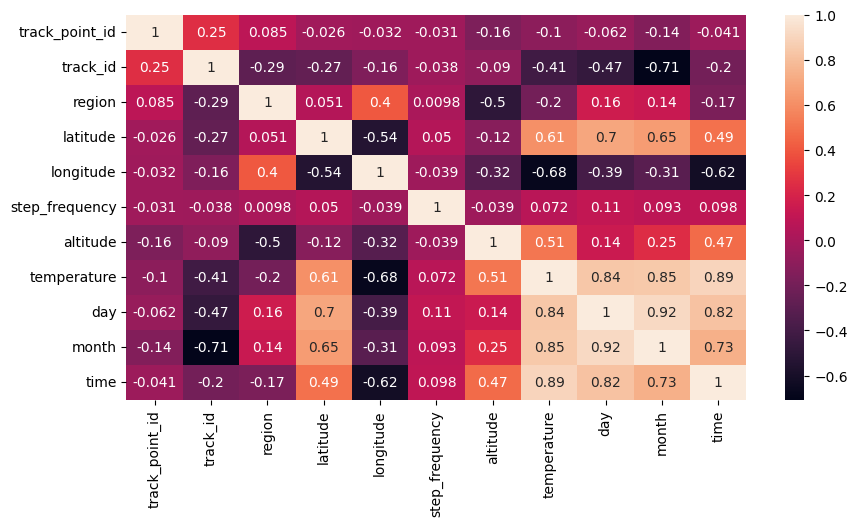

In [89]:
plt.figure(figsize=(10, 5))
sns.heatmap(all_df.corr(), annot=True)

Наиболее важные признаки - это высота, долгота и широта, также хорошо коррелируют температура и сезонные признаки

# 1.4 Описание структуры набора данных

track_point_id - ID точки


track_id - ID трека


region - регион, в котором находится точка


latitude - широта


longitude - долгота


step_frequency - частота шагов (шаг/мин)


altitude - высота (метры)


temperature - температура в градусах по Цельсию


day - день месяца


month - месяц года


time - секунды от начала дня